In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

In [3]:
from sklearn.datasets import fetch_covtype
df = fetch_covtype(as_frame=True)
df = pd.concat([df['data'], df['target']], axis=1)
df.head(5)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1                   5

In [5]:
df['Cover_Type'].unique()

array([5, 2, 1, 7, 3, 6, 4], dtype=int32)

In [6]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [7]:
df['Soil_Type_18'].unique()

array([0., 1.])

In [8]:
df['Cover_Type'].value_counts()

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [9]:
df['Cover_Type'] = df['Cover_Type'] - 1
df['Cover_Type'].value_counts()

Cover_Type
1    283301
0    211840
2     35754
6     20510
5     17367
4      9493
3      2747
Name: count, dtype: int64

In [10]:
NUM_CLASSES = 7

In [11]:
from sklearn.model_selection import train_test_split
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=11,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=11,stratify=y_val_test)


In [12]:
# Class weights (only from y_train)
counts = np.bincount(y_train, minlength=NUM_CLASSES)
weights = 1.0 / np.sqrt(counts)
class_weights = torch.tensor(weights / weights.mean(), dtype=torch.float32)
class_weights

tensor([0.2856, 0.2470, 0.6952, 2.5078, 1.3492, 0.9974, 0.9179])

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

binary_cols: list[str] = [
    c for c in X_train.columns if c.startswith(("Wilderness_Area", "Soil_Type"))
]
numeric_cols: list[str] = [c for c in X_train.columns if c not in binary_cols]

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_cols),  # scale continuous features
        ("bin", "passthrough", binary_cols),      # keep one-hot as 0/1
    ],
    verbose_feature_names_out=False,
)

X_train_np = preprocessor.fit_transform(X_train).astype(np.float32)  # fit on train only
X_val_np = preprocessor.transform(X_val).astype(np.float32)
X_test_np = preprocessor.transform(X_test).astype(np.float32)

X_train_tensor = torch.from_numpy(X_train_np)
X_val_tensor = torch.from_numpy(X_val_np)
X_test_tensor = torch.from_numpy(X_test_np)

y_train_tensor = torch.from_numpy(y_train.to_numpy()).long()
y_val_tensor = torch.from_numpy(y_val.to_numpy()).long()
y_test_tensor = torch.from_numpy(y_test.to_numpy()).long()

print(X_train_tensor.size()[1])
y_train_tensor.unique().size()[0]

54


C:\Users\User\AppData\Local\Temp\ipykernel_16472\3230176154.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.from_numpy(y_train.to_numpy()).long()


7

In [14]:
from torch import nn
class CoverTypeClassifier(nn.Module):
  def __init__(self,input_size,num_class):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(input_size,128),nn.BatchNorm1d(128),nn.ReLU(),
        nn.Linear(128,128),nn.BatchNorm1d(128),nn.ReLU(),
        nn.Linear(128,128),nn.BatchNorm1d(128),nn.ReLU(),
        nn.Linear(128,64),nn.BatchNorm1d(64),nn.ReLU(),
        nn.Linear(64,32),nn.BatchNorm1d(32),nn.ReLU(),
        nn.Linear(32,7),nn.BatchNorm1d(7)
    )

  def forward(self,x: torch.Tensor) -> torch.Tensor:
    return self.layers(x)

In [15]:
torch.manual_seed(11)

input_size = X_train_tensor.size()[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

model = CoverTypeClassifier(input_size,NUM_CLASSES).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

device

device(type='cuda')

In [16]:
import time

import torch
from torchmetrics.classification import MulticlassAccuracy

EPOCHS = 100
BATCH_SIZE = 1024
n = X_train_tensor.shape[0]

# Separate metric objects for train and val; "micro" = standard accuracy
train_acc_metric = MulticlassAccuracy(num_classes=NUM_CLASSES, average="micro").to(device)
val_acc_metric = MulticlassAccuracy(num_classes=NUM_CLASSES, average="micro").to(device)

train_loss_history: list[float] = []
val_loss_history: list[float] = []
train_acc_history: list[float] = []
val_acc_history: list[float] = []

for epoch in range(EPOCHS):
    start = time.perf_counter()

    # ---- Train ----
    model.train()
    train_acc_metric.reset()
    running_loss = torch.zeros((), device=device)  # accumulate on GPU, no per-batch sync

    perm = torch.randperm(n, device=device)
    for i in range(0, n, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        X_batch, y_batch = X_train_tensor[idx], y_train_tensor[idx]

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.detach() * y_batch.size(0)
        train_acc_metric.update(logits.detach().argmax(dim=1), y_batch)

    train_loss = (running_loss / n).item()
    train_acc = train_acc_metric.compute().item()

    # ---- Validation ----
    model.eval()
    val_acc_metric.reset()
    with torch.inference_mode():
        val_logits = model(X_val_tensor)
        val_loss = loss_fn(val_logits, y_val_tensor).item()
        val_acc_metric.update(val_logits.argmax(dim=1), y_val_tensor)
        val_acc = val_acc_metric.compute().item()

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    print(
        f"Epoch {epoch + 1:3d}/{EPOCHS} | "
        f"train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | "
        f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f} | "
        f"{elapsed:.2f}s"
    )

Epoch   1/100 | train_loss 0.8581 | train_acc 0.7449 | val_loss 0.6327 | val_acc 0.8153 | 3.93s
Epoch   2/100 | train_loss 0.5217 | train_acc 0.8432 | val_loss 0.4486 | val_acc 0.8625 | 2.91s
Epoch   3/100 | train_loss 0.4040 | train_acc 0.8688 | val_loss 0.3733 | val_acc 0.8691 | 2.77s
Epoch   4/100 | train_loss 0.3422 | train_acc 0.8829 | val_loss 0.3156 | val_acc 0.8879 | 2.73s
Epoch   5/100 | train_loss 0.3040 | train_acc 0.8922 | val_loss 0.2992 | val_acc 0.8957 | 2.19s
Epoch   6/100 | train_loss 0.2777 | train_acc 0.8994 | val_loss 0.2751 | val_acc 0.9021 | 1.69s
Epoch   7/100 | train_loss 0.2568 | train_acc 0.9039 | val_loss 0.2673 | val_acc 0.8986 | 2.14s
Epoch   8/100 | train_loss 0.2433 | train_acc 0.9086 | val_loss 0.2471 | val_acc 0.9061 | 3.73s
Epoch   9/100 | train_loss 0.2325 | train_acc 0.9118 | val_loss 0.2325 | val_acc 0.9146 | 3.60s
Epoch  10/100 | train_loss 0.2222 | train_acc 0.9144 | val_loss 0.2282 | val_acc 0.9143 | 3.63s
Epoch  11/100 | train_loss 0.2111 | trai

# Model Evaluation & Diagnostics

This section evaluates the trained `CoverTypeClassifier` from two angles:

1. **Learning dynamics** — how loss and accuracy evolved on the train and validation splits during training.
2. **Final-model performance** — threshold-free and threshold-based metrics on the held-out **validation** and **test** splits.

Because the Cover Type dataset is **highly imbalanced** (the two majority classes cover ~85% of samples), plain accuracy is not sufficient. We therefore also report macro-averaged F1, balanced accuracy, Cohen's κ, MCC, one-vs-rest ROC-AUC and PR-AUC, plus per-class breakdowns.

> **Note:** all metrics below are computed with the model weights from the **last** training epoch (no best-checkpoint restore).

## 1. Setup — plotting style, class names and predictions

Shared configuration for every plot below:

- A consistent, colorblind-validated categorical palette (fixed order: one color per class, never re-assigned).
- Human-readable class names (UCI Covertype, labels shifted to `0..6`).
- A batched inference helper that returns **softmax probabilities** — every downstream metric is derived from these, so the model is run only once per split.

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from matplotlib.ticker import MaxNLocator, PercentFormatter
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

# ---- Class metadata (UCI Covertype, labels shifted to 0..6) ----
CLASS_NAMES: list[str] = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz",
]

# ---- Palette: fixed-order categorical slots (CVD-validated) ----
CLASS_COLORS: list[str] = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
]
SPLIT_COLORS: dict[str, str] = {"Train": "#2a78d6", "Validation": "#eb6834", "Test": "#1baf7a"}
INK_PRIMARY, INK_SECONDARY, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e0"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 200,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": INK_MUTED,
        "axes.labelcolor": INK_SECONDARY,
        "axes.titlecolor": INK_PRIMARY,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.labelsize": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SECONDARY,
        "ytick.color": INK_SECONDARY,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2.0,
        "font.size": 10,
    }
)


@torch.inference_mode()
def predict_proba(
    model: torch.nn.Module, X: torch.Tensor, batch_size: int = 16_384
) -> np.ndarray:
    """Batched inference -> softmax probabilities of shape (N, NUM_CLASSES)."""
    model.eval()
    probs: list[torch.Tensor] = []
    for i in range(0, X.size(0), batch_size):
        logits = model(X[i : i + batch_size].to(device, non_blocking=True))
        probs.append(torch.softmax(logits.float(), dim=1).cpu())
    return torch.cat(probs).numpy()


# ---- Predictions for every evaluation split ----
EVAL_SPLITS: dict[str, dict[str, np.ndarray]] = {}
for split_name, X_split, y_split in [
    ("Validation", X_val_tensor, y_val_tensor),
    ("Test", X_test_tensor, y_test_tensor),
]:
    proba = predict_proba(model, X_split)
    EVAL_SPLITS[split_name] = {
        "y_true": y_split.cpu().numpy(),
        "y_proba": proba,
        "y_pred": proba.argmax(axis=1),
    }

epochs = np.arange(1, len(train_loss_history) + 1)
for name, d in EVAL_SPLITS.items():
    print(f"{name:<10} | n = {len(d['y_true']):>7,} | accuracy = {accuracy_score(d['y_true'], d['y_pred']):.4f}")

Validation | n =  58,101 | accuracy = 0.9507
Test       | n =  58,102 | accuracy = 0.9535


## 2. Learning curves — Loss

Train vs. validation **class-weighted cross-entropy** per epoch. The dashed marker highlights the epoch with the lowest validation loss — a natural candidate for early stopping / checkpoint selection.

**How to read it:**
- Both curves decreasing together → the model is still learning useful structure.
- Validation loss flattening or rising while training loss keeps falling → onset of overfitting.
- Validation loss below training loss early on is expected here: training loss is averaged over the epoch while weights are still changing (and BatchNorm runs in train mode), whereas validation is measured once at the end of the epoch in eval mode.

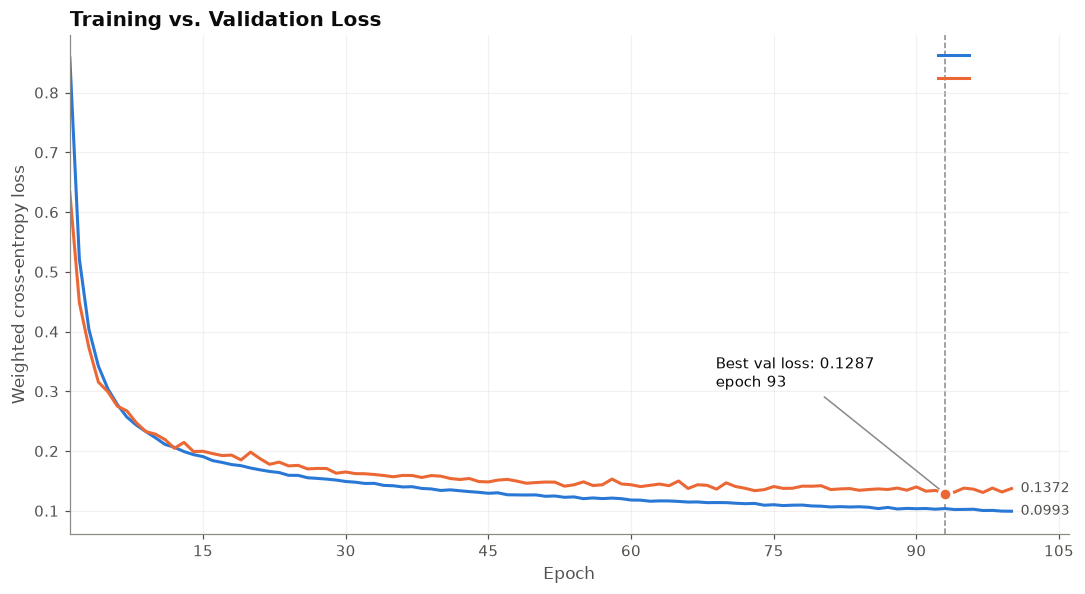

In [30]:
best_loss_epoch = int(np.argmin(val_loss_history)) + 1
best_loss = val_loss_history[best_loss_epoch - 1]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(epochs, train_loss_history, color=SPLIT_COLORS["Train"], label="Train")
ax.plot(epochs, val_loss_history, color=SPLIT_COLORS["Validation"], label="Validation")

ax.axvline(best_loss_epoch, color=INK_MUTED, ls="--", lw=1, zorder=0)
ax.scatter(best_loss_epoch, best_loss, s=70, color=SPLIT_COLORS["Validation"],
           edgecolor="white", linewidth=2, zorder=5)
ax.annotate(
    f"Best val loss: {best_loss:.4f}\nepoch {best_loss_epoch}",
    xy=(best_loss_epoch, best_loss),
    xytext=(-150, 70), textcoords="offset points",
    fontsize=10, color=INK_PRIMARY,
    arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=1),
)

# Final-epoch values as direct labels
for series, color in [(train_loss_history, SPLIT_COLORS["Train"]),
                      (val_loss_history, SPLIT_COLORS["Validation"])]:
    ax.annotate(f"{series[-1]:.4f}", xy=(epochs[-1], series[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK_SECONDARY)

ax.set(title="Training vs. Validation Loss", xlabel="Epoch", ylabel="Weighted cross-entropy loss",
       xlim=(1, epochs[-1] + max(2, len(epochs) * 0.06)))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## 3. Learning curves — Accuracy

Train vs. validation **accuracy** per epoch (micro-averaged, i.e. the fraction of correctly classified samples). The marker shows the epoch with the highest validation accuracy.

Keep in mind that accuracy is dominated by the two majority classes (*Spruce/Fir*, *Lodgepole Pine*); the class-balanced view is given by the metrics in the following sections.

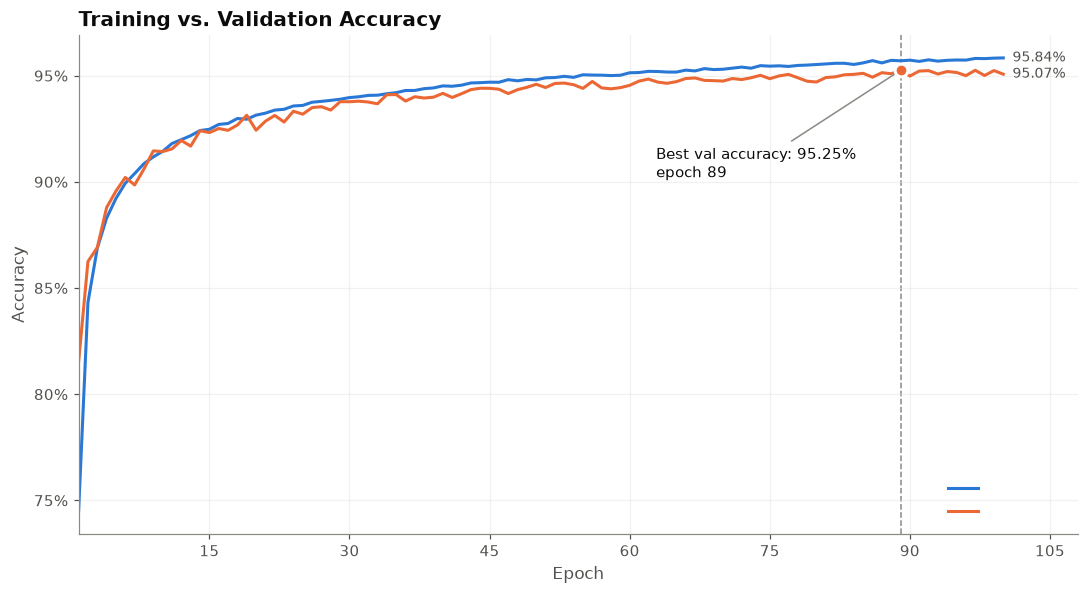

In [19]:
best_acc_epoch = int(np.argmax(val_acc_history)) + 1
best_acc = val_acc_history[best_acc_epoch - 1]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(epochs, train_acc_history, color=SPLIT_COLORS["Train"], label="Train")
ax.plot(epochs, val_acc_history, color=SPLIT_COLORS["Validation"], label="Validation")

ax.axvline(best_acc_epoch, color=INK_MUTED, ls="--", lw=1, zorder=0)
ax.scatter(best_acc_epoch, best_acc, s=70, color=SPLIT_COLORS["Validation"],
           edgecolor="white", linewidth=2, zorder=5)
ax.annotate(
    f"Best val accuracy: {best_acc:.2%}\nepoch {best_acc_epoch}",
    xy=(best_acc_epoch, best_acc),
    xytext=(-160, -70), textcoords="offset points",
    fontsize=10, color=INK_PRIMARY,
    arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=1),
)

for series in (train_acc_history, val_acc_history):
    ax.annotate(f"{series[-1]:.2%}", xy=(epochs[-1], series[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK_SECONDARY)

ax.set(title="Training vs. Validation Accuracy", xlabel="Epoch", ylabel="Accuracy",
       xlim=(1, epochs[-1] + max(2, len(epochs) * 0.08)))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 4. Generalization gap

The **generalization gap** isolates the difference between the two splits, which is hard to judge from the raw curves when both are close:

- **Loss gap** = `val_loss − train_loss` (positive → validation is worse).
- **Accuracy gap** = `train_acc − val_acc` (positive → training is better).

A gap that stays near zero indicates good generalization; a steadily **growing positive gap** is the clearest signal of overfitting. A light moving average (window = 5) is overlaid to separate the trend from epoch-to-epoch noise.

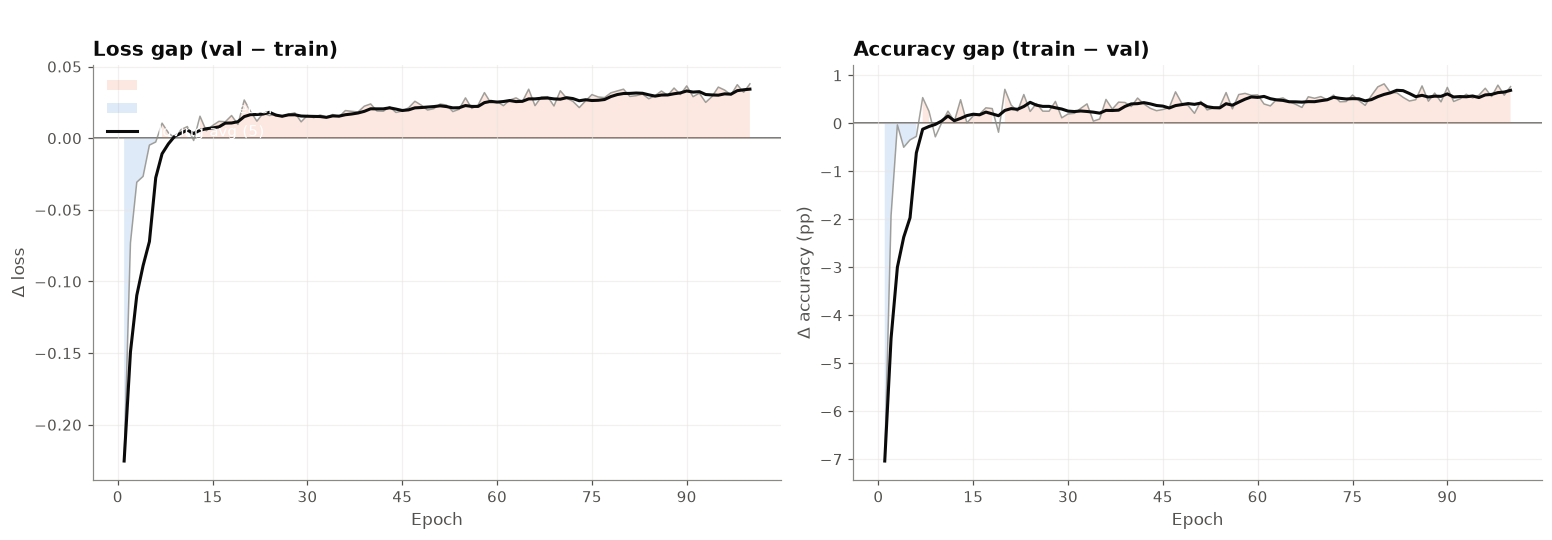

Final loss gap:     +0.0379
Final accuracy gap: +0.77 pp


In [31]:
def moving_average(x: np.ndarray, window: int = 5) -> np.ndarray:
    """Trailing moving average with a shrinking window at the start (same length as input)."""
    s = pd.Series(x)
    return s.rolling(window=window, min_periods=1).mean().to_numpy()


loss_gap = np.asarray(val_loss_history) - np.asarray(train_loss_history)
acc_gap = np.asarray(train_acc_history) - np.asarray(val_acc_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True, layout="constrained")
panels = [
    (axes[0], loss_gap, "Loss gap (val − train)", "Δ loss", False),
    (axes[1], acc_gap, "Accuracy gap (train − val)", "Δ accuracy (pp)", True),
]
for ax, gap, title, ylabel, is_pct in panels:
    y = gap * 100 if is_pct else gap
    ax.axhline(0, color=INK_SECONDARY, lw=1, zorder=1)
    ax.fill_between(epochs, 0, y, where=y >= 0, color=SPLIT_COLORS["Validation"], alpha=0.15,
                    linewidth=0, label="Validation worse")
    ax.fill_between(epochs, 0, y, where=y < 0, color=SPLIT_COLORS["Train"], alpha=0.15,
                    linewidth=0, label="Validation better")
    ax.plot(epochs, y, color=INK_MUTED, lw=1, alpha=0.8)
    ax.plot(epochs, moving_average(y), color=INK_PRIMARY, lw=2, label="Moving avg (5)")
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

axes[0].legend(loc="upper left")
fig.suptitle("Generalization Gap over Training", x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.show()

print(f"Final loss gap:     {loss_gap[-1]:+.4f}")
print(f"Final accuracy gap: {acc_gap[-1] * 100:+.2f} pp")

## 5. Overall metrics — Validation vs. Test

A summary table of aggregate metrics on both held-out splits. For an imbalanced multiclass problem the most informative ones are:

| Metric | What it tells you |
|---|---|
| **Balanced accuracy** | Mean per-class recall — every class counts equally. |
| **Macro F1** | Unweighted mean of per-class F1 — penalizes weak minority-class performance. |
| **Weighted F1** | Per-class F1 weighted by support — close to accuracy on imbalanced data. |
| **Cohen's κ / MCC** | Agreement corrected for chance; robust single-number summaries for imbalanced labels. |
| **ROC-AUC (macro, OvR)** | Threshold-free ranking quality, averaged over one-vs-rest problems. |
| **PR-AUC (macro)** | Average precision per class — more sensitive than ROC-AUC to errors on rare classes. |
| **Log loss** | Unweighted cross-entropy of the predicted probabilities (lower is better; not on the 0–1 scale, so shown only in the table). |

Similar validation and test values confirm that the validation split is a reliable proxy for unseen data.

,Validation,Test
Accuracy,0.9507,0.9535
Balanced accuracy,0.9451,0.9492
Macro precision,0.8976,0.8980
Macro recall,0.9451,0.9492
Macro F1,0.9199,0.9218
Weighted F1,0.9509,0.9538
Cohen's κ,0.9213,0.9258
MCC,0.9214,0.9259
"ROC-AUC (macro, OvR)",0.9976,0.9980
PR-AUC (macro),0.9759,0.9786


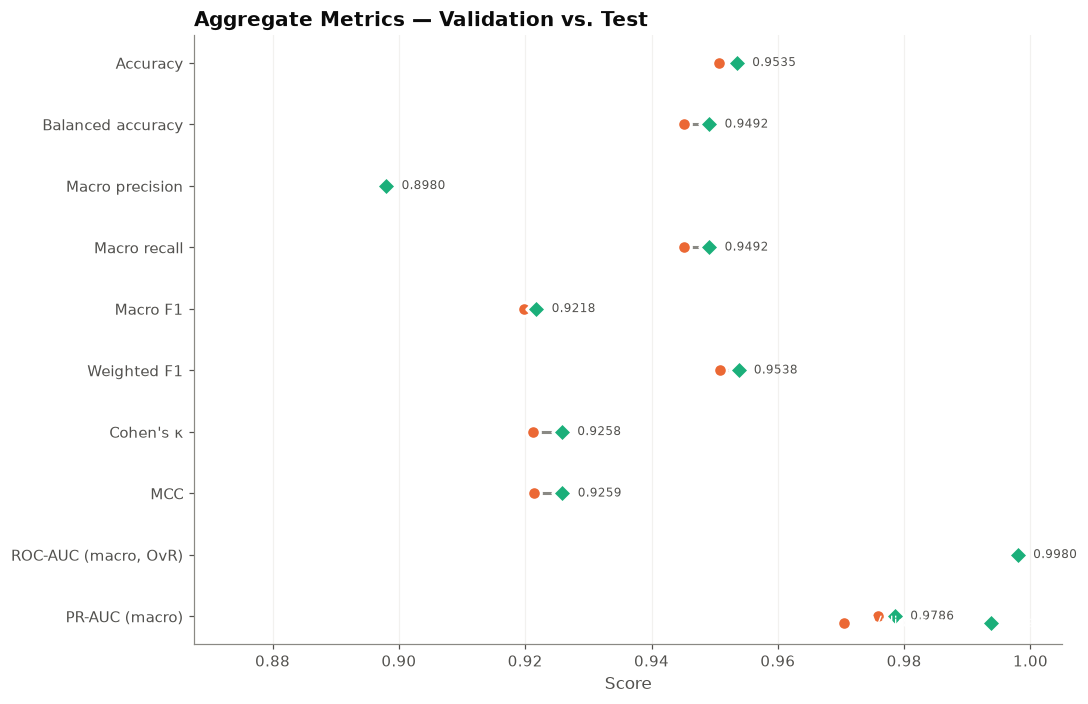

In [21]:
def compute_metrics(y_true: np.ndarray, y_proba: np.ndarray) -> dict[str, float]:
    """Aggregate classification metrics from true labels and class probabilities."""
    y_pred = y_proba.argmax(axis=1)
    y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Cohen's κ": cohen_kappa_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC-AUC (macro, OvR)": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
        "PR-AUC (macro)": average_precision_score(y_true_bin, y_proba, average="macro"),
        "Log loss": log_loss(y_true, y_proba, labels=np.arange(NUM_CLASSES)),
    }


metrics_df = pd.DataFrame(
    {name: compute_metrics(d["y_true"], d["y_proba"]) for name, d in EVAL_SPLITS.items()}
)
display(metrics_df.style.format("{:.4f}").set_caption("Aggregate metrics (last-epoch weights)"))

# ---- Chart: every metric bounded in [0, 1] (log loss excluded) ----
# Dot plot: a truncated x-axis is honest for dots (unlike bars), so small differences stay visible.
plot_df = metrics_df.drop(index="Log loss").iloc[::-1]  # reverse so the table order reads top-down
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.hlines(y_pos, plot_df.min(axis=1), plot_df.max(axis=1), color=INK_MUTED, lw=2, zorder=2)
for split, marker in zip(plot_df.columns, ("o", "D")):
    ax.scatter(plot_df[split], y_pos, s=80, marker=marker, color=SPLIT_COLORS[split],
               edgecolor="white", linewidth=2, label=split, zorder=3)
for y, (_, row) in zip(y_pos, plot_df.iterrows()):
    ax.annotate(f"{row.max():.4f}", xy=(row.max(), y), xytext=(10, 0), textcoords="offset points",
                va="center", fontsize=8, color=INK_SECONDARY)

ax.set_yticks(y_pos, plot_df.index)
lo = max(0.0, float(plot_df.to_numpy().min()) - 0.03)
ax.set(xlim=(lo, 1.005), xlabel="Score", title="Aggregate Metrics — Validation vs. Test")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", ncols=2)
fig.tight_layout()
plt.show()

## 6. Confusion matrix (Test set)

Two complementary views on the **test** split:

- **Left — absolute counts:** where the bulk of the errors are in absolute terms.
- **Right — row-normalized (recall):** each row sums to 1, so the diagonal is the per-class recall and off-diagonal cells show *which class a given class is confused with*, independently of class size.

On Cover Type the dominant confusion is typically between *Spruce/Fir* and *Lodgepole Pine*, which occupy similar elevation ranges.

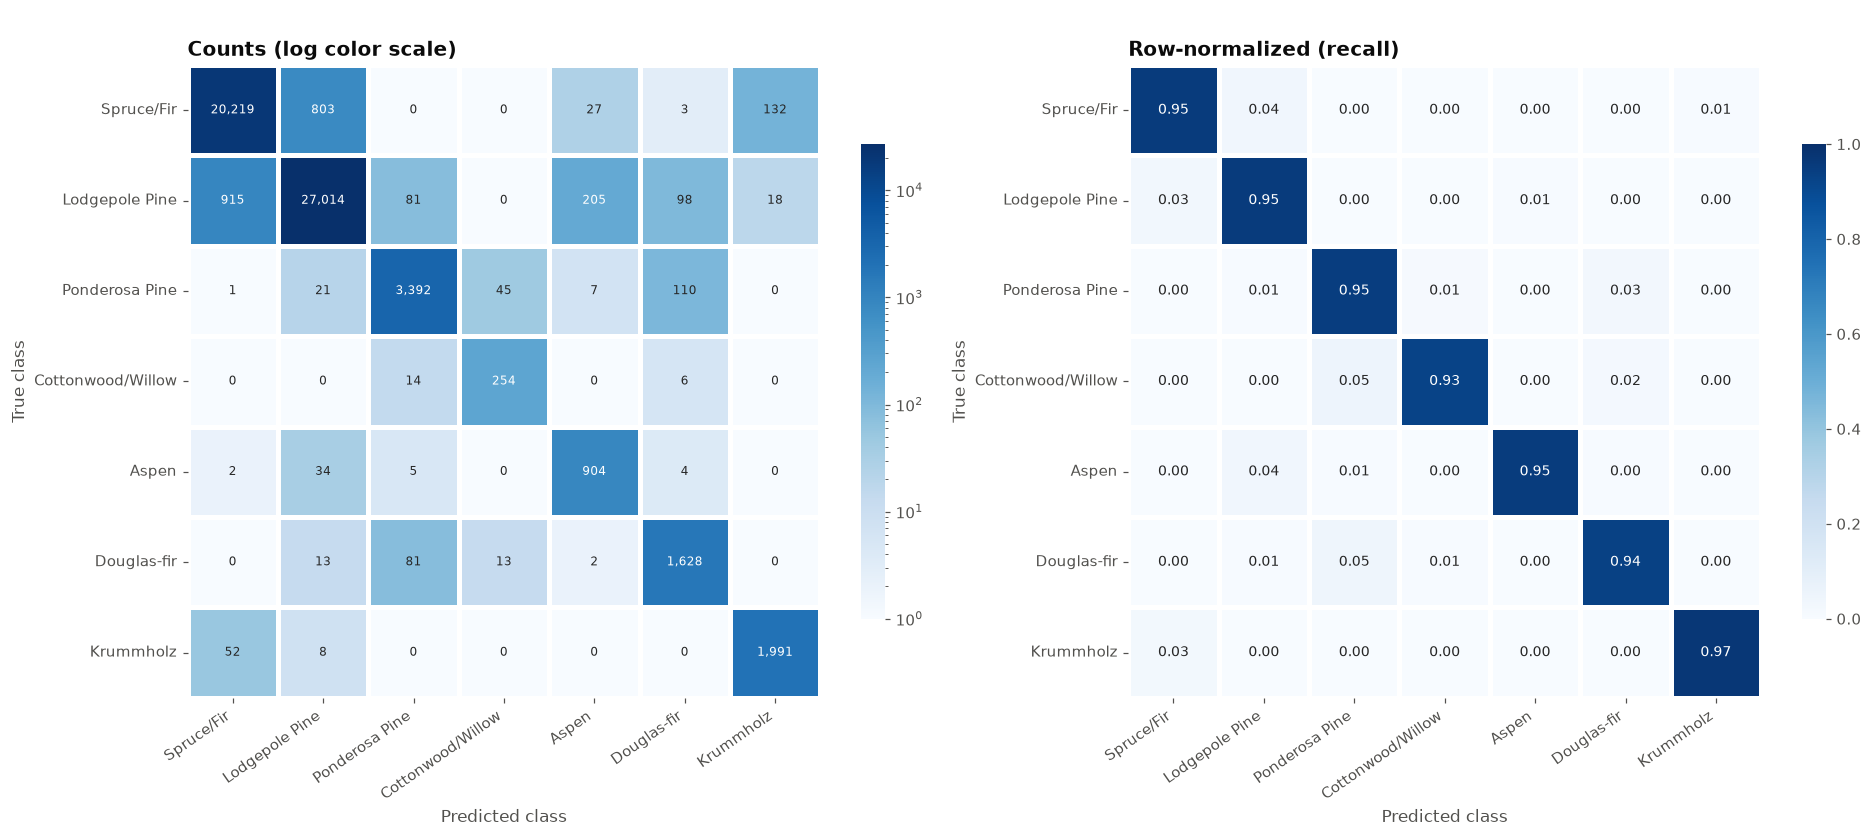

In [22]:
d = EVAL_SPLITS["Test"]
cm = confusion_matrix(d["y_true"], d["y_pred"], labels=np.arange(NUM_CLASSES))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), layout="constrained")
heatmap_kw = dict(
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, square=True,
    linewidths=2, linecolor="white", cbar_kws={"shrink": 0.75},
)

# Clip zeros to 1 only for the log color scale; annotations still show the true counts.
sns.heatmap(np.clip(cm, 1, None), ax=axes[0], cmap="Blues", annot=cm, fmt=",", annot_kws={"fontsize": 8},
            norm=plt.matplotlib.colors.LogNorm(vmin=1, vmax=cm.max()), **heatmap_kw)
axes[0].set_title("Counts (log color scale)")

sns.heatmap(cm_norm, ax=axes[1], cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f",
            annot_kws={"fontsize": 9}, **heatmap_kw)
axes[1].set_title("Row-normalized (recall)")

for ax in axes:
    ax.set(xlabel="Predicted class", ylabel="True class")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)
    ax.grid(False)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

fig.suptitle(f"Confusion Matrix — Test set (n = {len(d['y_true']):,})",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.show()

## 7. Per-class Precision, Recall and F1 (Test set)

Aggregate scores can hide weak classes. This breakdown shows, for each cover type:

- **Precision** — of the samples predicted as this class, how many are correct.
- **Recall** — of the samples truly in this class, how many were found.
- **F1** — harmonic mean of the two.

Class **support** (number of test samples) is shown under each label, making it easy to relate performance to class frequency. The class-weighted loss used in training is intended to lift recall on the rare classes (e.g. *Cottonwood/Willow*, *Aspen*).

,Precision,Recall,F1,Support
Spruce/Fir,0.9542,0.9544,0.9543,"21,184"
Lodgepole Pine,0.9685,0.9535,0.9609,"28,331"
Ponderosa Pine,0.9493,0.9485,0.9489,"3,576"
Cottonwood/Willow,0.8141,0.9270,0.8669,274
Aspen,0.7895,0.9526,0.8634,949
Douglas-fir,0.8805,0.9372,0.9080,"1,737"
Krummholz,0.9299,0.9707,0.9499,"2,051"


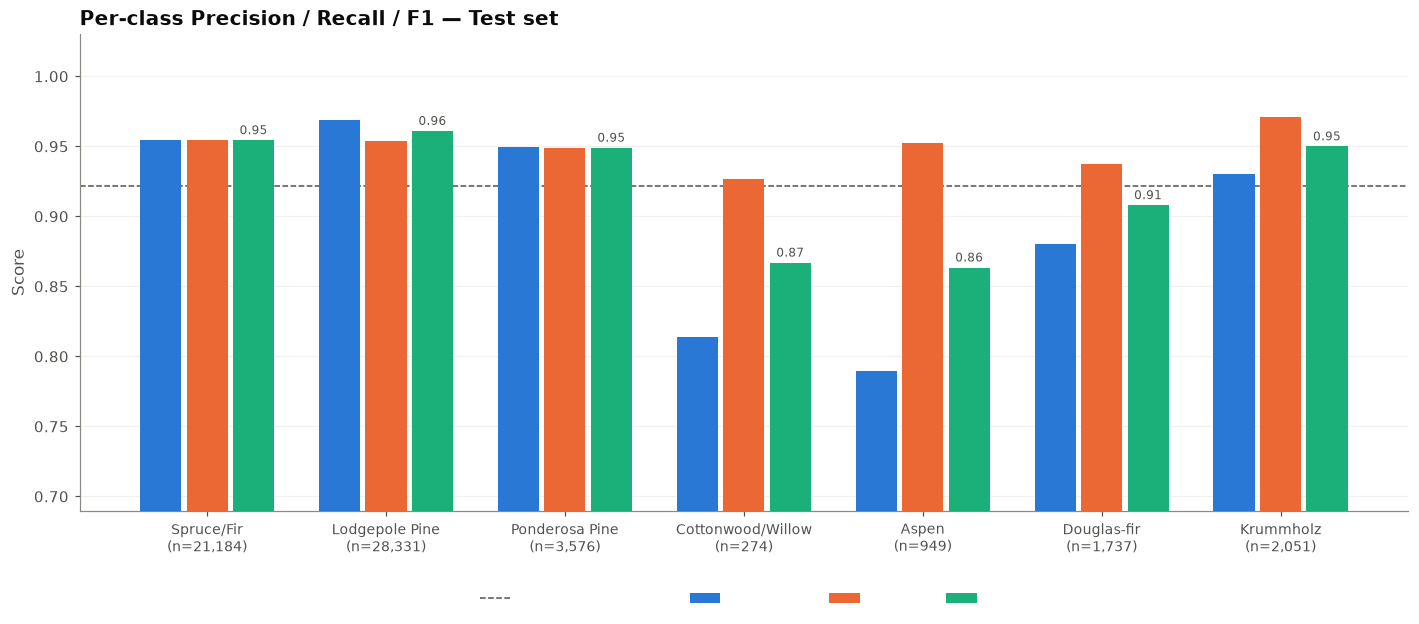

                   precision    recall  f1-score   support

       Spruce/Fir     0.9542    0.9544    0.9543     21184
   Lodgepole Pine     0.9685    0.9535    0.9609     28331
   Ponderosa Pine     0.9493    0.9485    0.9489      3576
Cottonwood/Willow     0.8141    0.9270    0.8669       274
            Aspen     0.7895    0.9526    0.8634       949
      Douglas-fir     0.8805    0.9372    0.9080      1737
        Krummholz     0.9299    0.9707    0.9499      2051

         accuracy                         0.9535     58102
        macro avg     0.8980    0.9492    0.9218     58102
     weighted avg     0.9545    0.9535    0.9538     58102



In [23]:
d = EVAL_SPLITS["Test"]
precision, recall, f1, support = precision_recall_fscore_support(
    d["y_true"], d["y_pred"], labels=np.arange(NUM_CLASSES), zero_division=0
)
per_class_df = pd.DataFrame(
    {"Precision": precision, "Recall": recall, "F1": f1, "Support": support}, index=CLASS_NAMES
)
display(
    per_class_df.style.format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}", "Support": "{:,}"})
    .background_gradient(subset=["F1"], cmap="Blues", vmin=0.5, vmax=1.0)
    .set_caption("Per-class metrics — Test set")
)

metric_colors = {"Precision": "#2a78d6", "Recall": "#eb6834", "F1": "#1baf7a"}
x = np.arange(NUM_CLASSES)
width = 0.26

fig, ax = plt.subplots(figsize=(13, 5.8))
for i, (metric, color) in enumerate(metric_colors.items()):
    bars = ax.bar(x + (i - 1) * width, per_class_df[metric], width=width - 0.03,
                  color=color, label=metric, zorder=3)
    if metric == "F1":  # label only F1 to keep the chart readable
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color=INK_SECONDARY)

macro_f1 = per_class_df["F1"].mean()
ax.axhline(macro_f1, color=INK_SECONDARY, ls="--", lw=1, zorder=2, label=f"Macro F1 = {macro_f1:.3f}")

ax.set_xticks(x, [f"{n}\n(n={s:,})" for n, s in zip(CLASS_NAMES, support)], fontsize=9)
ax.set(ylim=(max(0.0, per_class_df[["Precision", "Recall", "F1"]].to_numpy().min() - 0.1), 1.03),
       ylabel="Score", title="Per-class Precision / Recall / F1 — Test set")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=4)
fig.tight_layout()
plt.show()

print(classification_report(d["y_true"], d["y_pred"], target_names=CLASS_NAMES, digits=4))

## 8. ROC curves — One-vs-Rest (Test set)

For each class the multiclass problem is reduced to *this class vs. all others*, and the ROC curve is traced over all probability thresholds. The legend reports the per-class **AUC**, together with:

- **Micro-average** — pools all (sample, class) decisions; dominated by frequent classes.
- **Macro-average** — mean of per-class curves; treats every class equally.

With AUC values close to 1 the curves hug the top-left corner, so the right panel zooms into the low-FPR / high-TPR region where the classes actually differ.

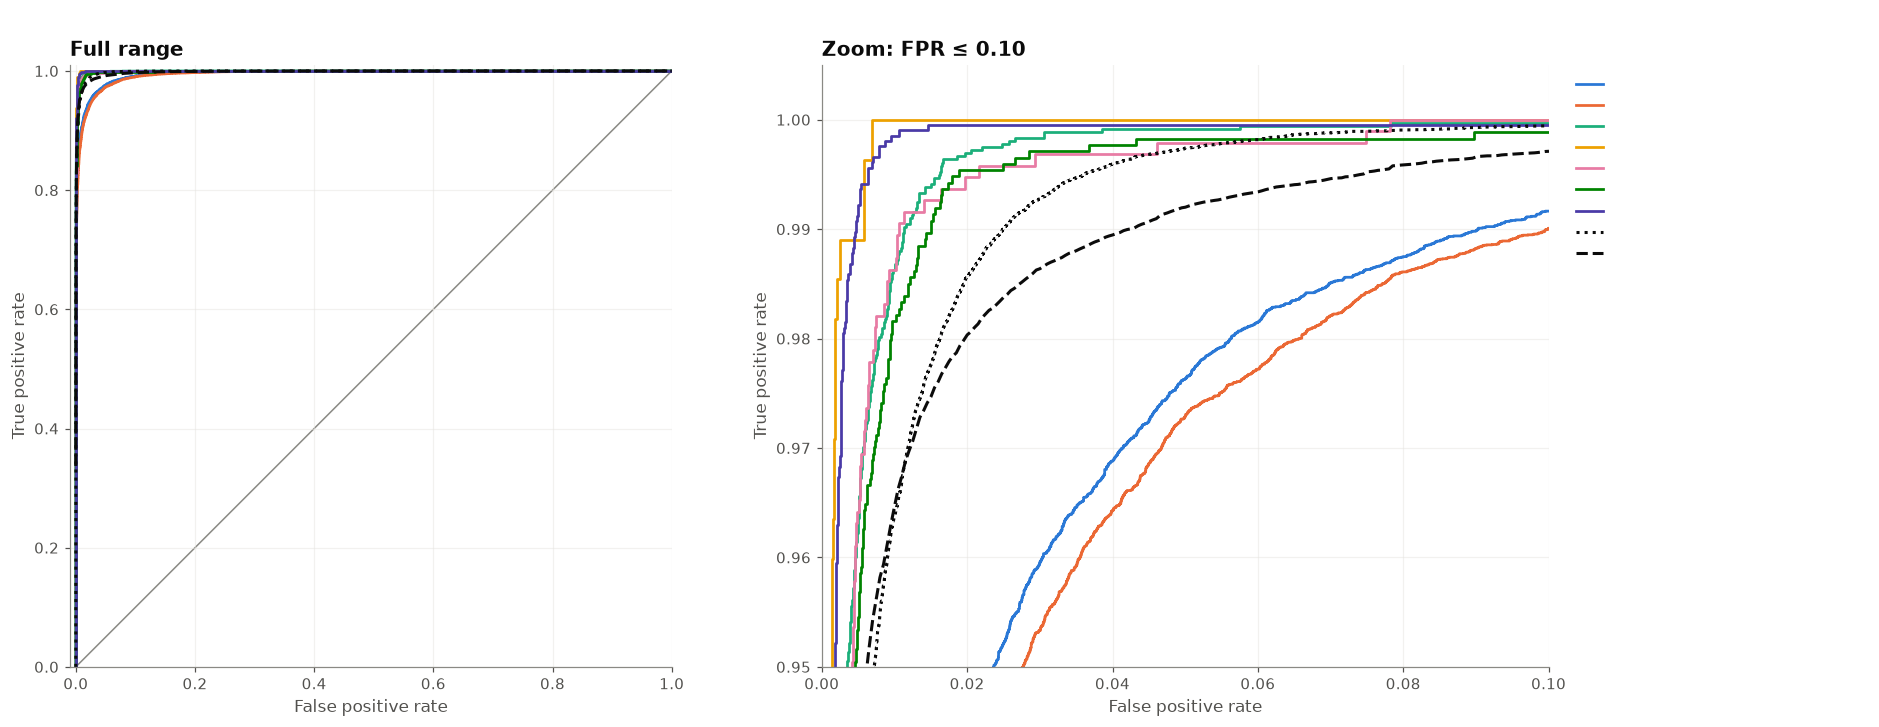

In [24]:
d = EVAL_SPLITS["Test"]
y_true_bin = label_binarize(d["y_true"], classes=np.arange(NUM_CLASSES))
y_proba = d["y_proba"]

fpr: dict[int | str, np.ndarray] = {}
tpr: dict[int | str, np.ndarray] = {}
roc_auc: dict[int | str, float] = {}
for k in range(NUM_CLASSES):
    fpr[k], tpr[k], _ = roc_curve(y_true_bin[:, k], y_proba[:, k])
    roc_auc[k] = auc(fpr[k], tpr[k])

# Micro-average: flatten all one-vs-rest decisions
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average: interpolate every class curve on a common FPR grid
fpr_grid = np.linspace(0.0, 1.0, 2_000)
mean_tpr = np.mean([np.interp(fpr_grid, fpr[k], tpr[k]) for k in range(NUM_CLASSES)], axis=0)
fpr["macro"], tpr["macro"] = fpr_grid, mean_tpr
roc_auc["macro"] = auc(fpr_grid, mean_tpr)

# Zoom window adapts to the weakest class so every curve stays visible
zoom_fpr = 0.10
tpr_floor = min(float(np.interp(zoom_fpr, fpr[k], tpr[k])) for k in range(NUM_CLASSES))
zoom_ylim = (max(0.0, np.floor((tpr_floor - 0.03) * 20) / 20), 1.005)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), layout="constrained")
for ax, zoom in zip(axes, (False, True)):
    for k in range(NUM_CLASSES):
        ax.plot(fpr[k], tpr[k], color=CLASS_COLORS[k], lw=1.8,
                label=f"{CLASS_NAMES[k]} (AUC = {roc_auc[k]:.4f})")
    ax.plot(fpr["micro"], tpr["micro"], color=INK_PRIMARY, lw=2, ls=":",
            label=f"Micro-average (AUC = {roc_auc['micro']:.4f})")
    ax.plot(fpr["macro"], tpr["macro"], color=INK_PRIMARY, lw=2, ls="--",
            label=f"Macro-average (AUC = {roc_auc['macro']:.4f})")
    ax.plot([0, 1], [0, 1], color=INK_MUTED, lw=1, ls="-", zorder=0)
    ax.set(xlabel="False positive rate", ylabel="True positive rate")
    if zoom:
        ax.set(xlim=(0, zoom_fpr), ylim=zoom_ylim, title=f"Zoom: FPR ≤ {zoom_fpr:.2f}")
    else:
        ax.set(xlim=(-0.01, 1), ylim=(0, 1.01), title="Full range")
        ax.set_aspect("equal")

axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9)
fig.suptitle("ROC Curves (One-vs-Rest) — Test set", x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.show()

## 9. Precision–Recall curves (Test set)

For imbalanced data, **precision–recall curves** are more informative than ROC: a model can reach a high ROC-AUC on a rare class while still producing many false positives relative to that class's true positives. PR curves expose this directly.

- The legend reports **Average Precision (AP)** per class — the area under the PR curve.
- The **baseline** in the legend is each class's prevalence, i.e. the AP of a random classifier for that class. The larger the margin between AP and baseline, the more skill the model has on that class.

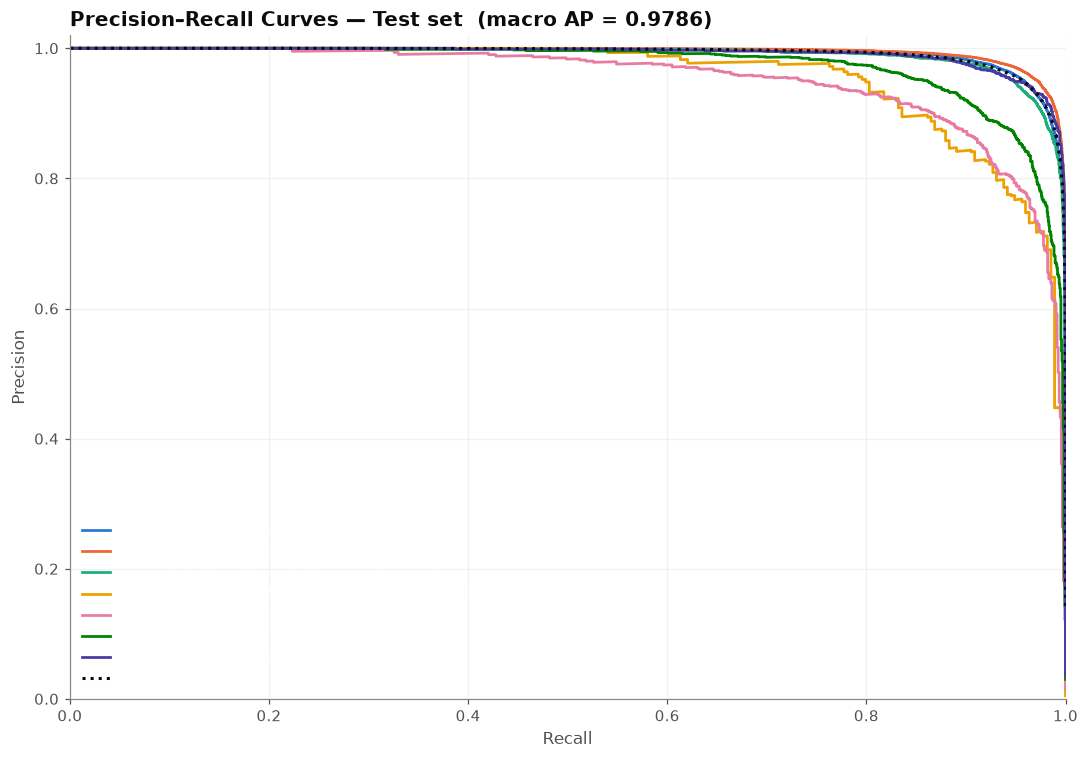

In [25]:
d = EVAL_SPLITS["Test"]
y_true_bin = label_binarize(d["y_true"], classes=np.arange(NUM_CLASSES))
y_proba = d["y_proba"]

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(NUM_CLASSES):
    prec_k, rec_k, _ = precision_recall_curve(y_true_bin[:, k], y_proba[:, k])
    ap_k = average_precision_score(y_true_bin[:, k], y_proba[:, k])
    prevalence = y_true_bin[:, k].mean()  # AP of a random classifier for this class
    ax.plot(rec_k, prec_k, color=CLASS_COLORS[k], lw=1.8,
            label=f"{CLASS_NAMES[k]} (AP = {ap_k:.4f}, baseline = {prevalence:.3f})")

prec_micro, rec_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_proba.ravel())
ap_micro = average_precision_score(y_true_bin, y_proba, average="micro")
ap_macro = average_precision_score(y_true_bin, y_proba, average="macro")
ax.plot(rec_micro, prec_micro, color=INK_PRIMARY, lw=2, ls=":",
        label=f"Micro-average (AP = {ap_micro:.4f})")

ax.set(xlim=(0, 1.0), ylim=(0, 1.02), xlabel="Recall", ylabel="Precision",
       title=f"Precision–Recall Curves — Test set  (macro AP = {ap_macro:.4f})")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
plt.show()

## 10. Calibration — Reliability diagram (Test set)

A well-performing classifier is not necessarily **well calibrated**: its softmax confidence may not match the actual probability of being correct. This matters whenever the predicted probabilities are used downstream (thresholding, risk scoring, ensembling).

- **Left — reliability diagram:** top-1 confidence is binned; each point compares mean confidence (x) with the observed accuracy in that bin (y). Points **below** the diagonal mean *over-confidence*, points **above** mean *under-confidence*.
- **Right — confidence distribution:** top-1 confidence for correct vs. incorrect predictions. A good model concentrates correct predictions near 1.0 and spreads errors toward lower confidence.
- **ECE (Expected Calibration Error)** — the support-weighted average gap between confidence and accuracy (lower is better).

> Training with **class-weighted** cross-entropy deliberately shifts probability mass toward minority classes, which usually makes the model less calibrated on the natural class distribution. Temperature scaling on the validation set is the standard post-hoc fix.

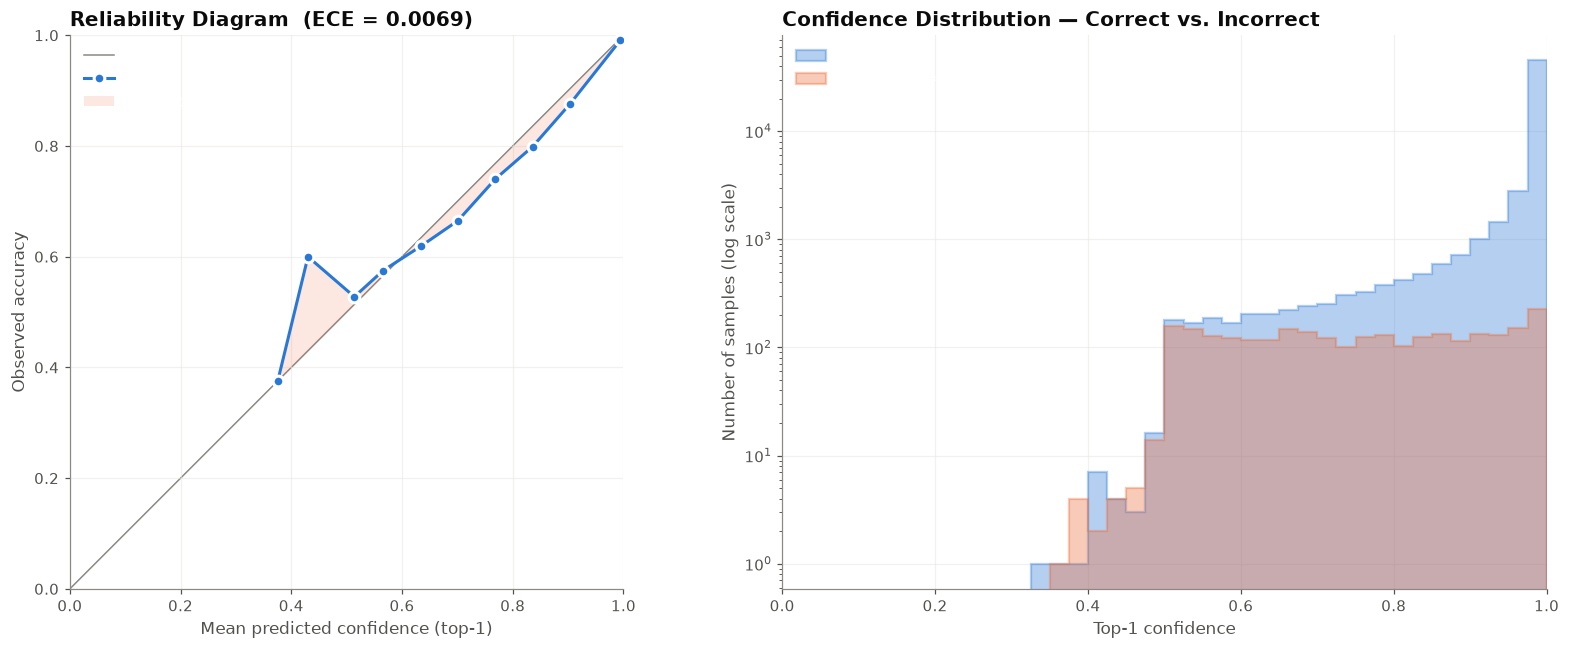

Mean confidence (correct):   0.9699
Mean confidence (incorrect): 0.7536


In [26]:
def expected_calibration_error(
    confidence: np.ndarray, correct: np.ndarray, n_bins: int = 15
) -> float:
    """ECE with equal-width confidence bins."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(confidence, edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(ece)


d = EVAL_SPLITS["Test"]
confidence = d["y_proba"].max(axis=1)
correct = (d["y_pred"] == d["y_true"]).astype(float)
ece = expected_calibration_error(confidence, correct)
frac_correct, mean_conf = calibration_curve(correct, confidence, n_bins=15, strategy="uniform")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Reliability diagram ----
ax = axes[0]
ax.plot([0, 1], [0, 1], color=INK_MUTED, lw=1, label="Perfect calibration", zorder=1)
ax.plot(mean_conf, frac_correct, color=SPLIT_COLORS["Train"], marker="o", ms=7,
        markeredgecolor="white", markeredgewidth=2, label="Model", zorder=3)
ax.fill_between(mean_conf, mean_conf, frac_correct, color=SPLIT_COLORS["Validation"],
                alpha=0.15, linewidth=0, label="Calibration gap", zorder=2)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted confidence (top-1)",
       ylabel="Observed accuracy", title=f"Reliability Diagram  (ECE = {ece:.4f})")
ax.set_aspect("equal")
ax.legend(loc="upper left")

# ---- Confidence histogram ----
ax = axes[1]
bins = np.linspace(0, 1, 41)
ax.hist(confidence[correct == 1], bins=bins, color=SPLIT_COLORS["Train"], alpha=0.35,
        histtype="stepfilled", edgecolor=SPLIT_COLORS["Train"], linewidth=1.5,
        label=f"Correct (n = {int(correct.sum()):,})", zorder=3)
ax.hist(confidence[correct == 0], bins=bins, color=SPLIT_COLORS["Validation"], alpha=0.35,
        histtype="stepfilled", edgecolor=SPLIT_COLORS["Validation"], linewidth=1.5,
        label=f"Incorrect (n = {int((1 - correct).sum()):,})", zorder=3)
ax.set_yscale("log")
ax.set_xlim(0, 1)
ax.set(xlabel="Top-1 confidence", ylabel="Number of samples (log scale)",
       title="Confidence Distribution — Correct vs. Incorrect")
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()

print(f"Mean confidence (correct):   {confidence[correct == 1].mean():.4f}")
print(f"Mean confidence (incorrect): {confidence[correct == 0].mean():.4f}")

## 11. Summary

The plots above cover the full evaluation picture:

| Aspect | Where to look |
|---|---|
| Convergence & overfitting | Loss / accuracy curves, generalization gap |
| Overall performance on unseen data | Aggregate metrics table (validation vs. test) |
| Class-level strengths & weaknesses | Confusion matrix, per-class P/R/F1 |
| Ranking quality (threshold-free) | ROC and Precision–Recall curves |
| Reliability of predicted probabilities | Reliability diagram & ECE |

**Possible next steps:** restore the best-validation checkpoint instead of last-epoch weights, add a learning-rate scheduler (e.g. `ReduceLROnPlateau` / `OneCycleLR`), track macro-F1 per epoch to use it as the early-stopping criterion, and apply temperature scaling if calibrated probabilities are required.